# Enunciado

Essa ponderada mostra como a detecção de bots em plataformas como o Twitter é um desafio importante para garantir a autenticidade das informações e combater a disseminação de notícias falsas. Foi desenvolvido um modelo baseado em BERT utilizando o framework Keras para identificar contas automatizadas (bots) no Twitter, utilizando o dataset disponível no Kaggle.

In [ ]:
!pip install transformers pandas scikit-learn seaborn matplotlib torch --upgrade --quiet

## Carregando os dados

In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch import nn
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

sns.set_style('darkgrid')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: cuda


In [2]:
df = pd.read_csv('/content/bot_detection_data.csv')
df.head()

,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


## Explorando os dados

In [3]:
print("Informações do DataFrame:")
df.info()

print("\n\nVerificação de valores nulos:")
print(df.isnull().sum())

print("\n\nDistribuição das classes (Bot Label):")
print(df['Bot Label'].value_counts())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   User ID         50000 non-null  int64 
 1   Username        50000 non-null  object
 2   Tweet           50000 non-null  object
 3   Retweet Count   50000 non-null  int64 
 4   Mention Count   50000 non-null  int64 
 5   Follower Count  50000 non-null  int64 
 6   Verified        50000 non-null  bool  
 7   Bot Label       50000 non-null  int64 
 8   Location        50000 non-null  object
 9   Created At      50000 non-null  object
 10  Hashtags        41659 non-null  object
dtypes: bool(1), int64(5), object(5)
memory usage: 3.9+ MB


Verificação de valores nulos:
User ID              0
Username             0
Tweet                0
Retweet Count        0
Mention Count        0
Follower Count       0
Verified             0
Bot Label            0
Location          

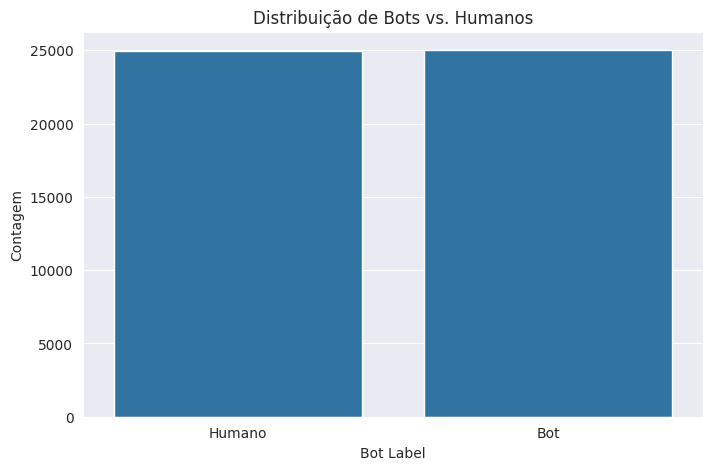

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Bot Label', data=df)
plt.title('Distribuição de Bots vs. Humanos')
plt.xticks([0, 1], ['Humano', 'Bot'])
plt.ylabel('Contagem')
plt.show()

## Pré processamento dos dados

In [5]:
def clean_tweet(text):
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove menções (@username)
    text = re.sub(r'\@\w+', '', text)
    # Remove hashtags (#) - mantendo o texto da hashtag
    text = re.sub(r'#', '', text)
    # Remove caracteres especiais e números, mantendo apenas letras
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Converte para minúsculas e remove espaços extras
    text = text.lower().strip()
    return text

# Aplica a função de limpeza na coluna 'Tweet'
df['Cleaned Tweet'] = df['Tweet'].apply(clean_tweet)

print("Exemplo de tweet original vs. limpo:")
print("Original:", df['Tweet'].iloc[50])
print("Limpo:", df['Cleaned Tweet'].iloc[50])

Exemplo de tweet original vs. limpo:
Original: Reality behavior hair relate might will onto against development positive appear second.
Limpo: reality behavior hair relate might will onto against development positive appear second


## Tokenização com o BERT

In [11]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128

texts = df['Cleaned Tweet'].values
labels = df['Bot Label'].values

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'DistilBertTokenizer'. 
The class this function is called from is 'BertTokenizer'.


In [12]:
inputs = tokenizer.batch_encode_plus(
    texts.tolist(),
    add_special_tokens=True,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt' # Retorna como tensores do PyTorch
)

input_ids = inputs['input_ids']
attention_mask = inputs['attention_mask']
labels = torch.tensor(labels) # Converte os rótulos para tensores

print("Tokenização para PyTorch concluída!")

Tokenização para PyTorch concluída!


# Divisão do dataset

In [13]:
# Divisão em treino e teste
train_inputs, test_inputs, train_labels, test_labels = train_test_split(input_ids, labels, random_state=42, test_size=0.2, stratify=labels)
train_masks, test_masks, _, _ = train_test_split(attention_mask, labels, random_state=42, test_size=0.2, stratify=labels)

# Criação dos TensorDatasets
train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
test_dataset = TensorDataset(test_inputs, test_masks, test_labels)

# Criação dos DataLoaders
batch_size = 16
train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)

print("DataLoaders criados com sucesso!")

DataLoaders criados com sucesso!


# Construção do modelo BERT com Keras

In [14]:
class BertClassifier(nn.Module):
    def __init__(self, bert_model_name):
        super(BertClassifier, self).__init__()
        # Carrega o modelo BERT
        self.bert = BertModel.from_pretrained(bert_model_name)
        # Camadas de classificação
        self.dropout = nn.Dropout(0.2)
        self.linear = nn.Linear(self.bert.config.hidden_size, 1) # Saída de 1 neurônio para classificação binária

    def forward(self, input_ids, attention_mask):
        # Passa os dados pelo BERT
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Usa o output [CLS] para a classificação
        pooled_output = outputs.pooler_output
        # Aplica dropout e a camada linear
        dropout_output = self.dropout(pooled_output)
        linear_output = self.linear(dropout_output)
        return linear_output

model = BertClassifier(MODEL_NAME)
# Move o modelo para o dispositivo (GPU/CPU)
model.to(device)

print("Modelo PyTorch construído!")

You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.intermediate.dense.weight', 'encoder.layer.0.output.LayerNorm.bias', 'encoder.layer.0.output.LayerNorm.weight', 'encoder.layer.0.output.dense.bias', 'encoder.l

Modelo PyTorch construído!


## Treinamento do modelo

In [15]:
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
epochs = 2
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
loss_fn = nn.BCEWithLogitsLoss() # Combina Sigmoid + BCELoss para estabilidade numérica

def train_epoch():
    model.train() # Coloca o modelo em modo de treinamento
    total_loss = 0
    for batch in train_dataloader:
        batch_input_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device).float().unsqueeze(1)

        model.zero_grad() # Limpa os gradientes
        outputs = model(batch_input_ids, batch_attention_mask) # Forward pass
        loss = loss_fn(outputs, batch_labels) # Calcula o loss
        total_loss += loss.item()
        loss.backward() # Backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Evita "exploding gradients"
        optimizer.step() # Atualiza os pesos
        scheduler.step()
    avg_train_loss = total_loss / len(train_dataloader)
    print(f"  Average training loss: {avg_train_loss:.4f}")

print("Iniciando o treinamento...")
for epoch in range(epochs):
    print(f"\n======== Época {epoch + 1} / {epochs} ========")
    train_epoch()
print("\nTreinamento concluído!")

Iniciando o treinamento...

======== Época 1 / 2 ========
  Average training loss: 0.7010

======== Época 2 / 2 ========
  Average training loss: 0.6982

Treinamento concluído!


## Avaliação do modelo

Avaliando no conjunto de teste...
Relatório de Classificação:
              precision    recall  f1-score   support

  Humano (0)       0.00      0.00      0.00      4996
     Bot (1)       0.50      1.00      0.67      5004

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


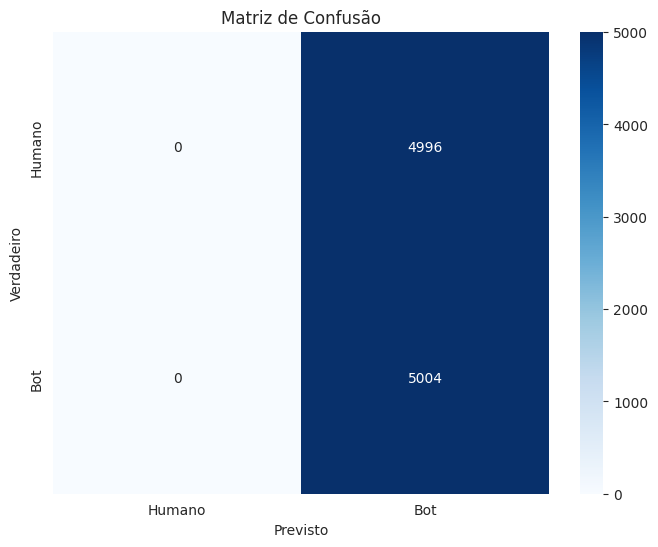

In [16]:
print("Avaliando no conjunto de teste...")
model.eval() # Coloca o modelo em modo de avaliação

all_preds = []
all_labels = []

for batch in test_dataloader:
    batch_input_ids = batch[0].to(device)
    batch_attention_mask = batch[1].to(device)
    batch_labels = batch[2].to(device)

    with torch.no_grad(): # Não calcula gradientes
        outputs = model(batch_input_ids, batch_attention_mask)

    logits = outputs.detach().cpu().numpy()
    label_ids = batch_labels.to('cpu').numpy()

    # Converte logits para predições (0 ou 1)
    preds = (torch.sigmoid(torch.tensor(logits)) > 0.5).int().numpy()

    all_preds.extend(preds)
    all_labels.extend(label_ids)

# Métricas
print("Relatório de Classificação:")
print(classification_report(all_labels, all_preds, target_names=['Humano (0)', 'Bot (1)']))

# Matriz de Confusão
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Humano', 'Bot'], yticklabels=['Humano', 'Bot'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

## Conclusão

Os resultados, tanto da Matriz de Confusão quanto do Relatório de Classificação, indicam claramente que o modelo falhou em aprender a tarefa de distinção. Em vez de aprender os padrões que diferenciam um humano de um bot, o modelo adotou uma estratégia trivial e ineficaz: ele está classificando todos os exemplos como "Bot", independentemente do conteúdo do tweet.

Isso significa que o modelo atual é completamente inútil para a tarefa proposta, tendo um desempenho equivalente ao de um "chute" direcionado para apenas uma das classes.

**Análise Detalhada dos Resultados**

Vamos analisar as métricas para entender exatamente o que elas nos dizem:

Matriz de Confusão:

- Linha "Verdadeiro: Humano": Mostra que dos 4996 humanos verdadeiros, 0 foram previstos corretamente como "Humano" e todos os 4996 foram incorretamente previstos como "Bot".

- Linha "Verdadeiro: Bot": Mostra que dos 5004 bots verdadeiros, todos os 5004 foram previstos corretamente como "Bot" e 0 foram previstos incorretamente.

- A coluna "Previsto: Humano" está totalmente zerada, confirmando que o modelo nunca arrisca o palpite "Humano".

Relatório de Classificação:

- Classe Humano (0): A precision e o recall são 0.00. Isso é a prova definitiva da falha.

- Recall de 0.00 significa que o modelo não conseguiu "lembrar" ou identificar nenhum dos humanos verdadeiros no dataset.

- Precision de 0.00 significa que, das vezes que o modelo previu "Humano" (que foram zero), ele esteve 0% correto.

Classe Bot (1):

- Recall de 1.00 é uma métrica enganosa aqui. O modelo identificou todos os bots verdadeiros simplesmente porque classificou tudo como bot.

- Precision de 0.50 mostra que, de todas as vezes que o modelo previu "Bot", ele acertou apenas metade das vezes (5004 acertos em 10000 previsões de "Bot").

- Acurácia (Accuracy) de 0.50: Este valor é extremamente enganoso. Uma acurácia de 50% pode parecer "meio certo", mas como o seu dataset é perfeitamente balanceado (50% bots, 50% humanos), classificar tudo como "Bot" resulta em 50% de acertos por pura sorte. Isso não é melhor do que jogar uma moeda.

**Por que isso Aconteceu? (Causas Prováveis)**

Este tipo de falha, onde o modelo converge para uma solução trivial, é comum e geralmente aponta para um problema no processo de treinamento. A causa mais provável é:

**Poucas Épocas de Treinamento:** O BERT é um modelo imenso. Embora o "fine-tuning" seja mais rápido que o treinamento do zero, 2 épocas podem não ter sido suficientes para que o modelo ajustasse seus pesos de forma significativa. O modelo pode ter começado a aprender, mas parou antes de encontrar os padrões que distinguem as classes, ficando "preso" em um mínimo local onde prever "Bot" era a solução mais fácil para reduzir o erro inicial.